# eCommerce de Notebooks: Exploração inicial do dataset
### Carregamento da base

In [333]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/laptop_data.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


### Estrutura da Base:

In [334]:
## Metadados de todas as colunas existentes no Dataset: ##
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


##### 1. ANÁLISE DE PERFIL DAS COLUNAS

In [335]:
df.describe(include="all")
#df.columns

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
count,1303.00000,1303,1303,1303.000000,1303,1303,1303,1303,1303,1303,1303,1303.000000
unique,NaN,19,6,NaN,40,118,9,39,110,9,179,NaN
top,NaN,Dell,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,NaN,297,727,NaN,507,190,619,412,281,1072,121,NaN
mean,651.00000,NaN,NaN,15.017191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59870.042910
std,376.28801,NaN,NaN,1.426304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37243.201786
min,0.00000,NaN,NaN,10.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9270.720000
25%,325.50000,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31914.720000
50%,651.00000,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52054.560000
75%,976.50000,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79274.246400


##### 2. BUSCA POR VALORES NULOS

In [336]:
## Avaliando valores nulos ##
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

##### 3. DROP DE COLUNAS DESNECESSÁRIAS

In [337]:
##identifiquei que a coluna índice 'Unnamed' padrão do arquivo csv era uma coluna desnecessária. Portando, irá para a exclusão.
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


#### 4. LIMPEZA DE COLUNAS 

In [338]:
#identifiquei que as colunas RAM e WEIGHT possuem "gb" e "kg" concatenado a valores numéricos e calculáveis. 
#df[["Ram", "Weight", "Price"]].head()

##Limpeza por substituição de caracteres
df["Ram"] = (
    df["Ram"].str.replace("GB", "", regex=False).str.strip().astype(int)
)

df["Weight"] = (
    df["Weight"].str.replace("kg", "", regex=False).str.strip().astype(float)
)
df[["Ram", "Weight", "Price"]].head()


,Ram,Weight,Price
0,8,1.37,71378.6832
1,8,1.34,47895.5232
2,8,1.86,30636.0000
3,16,1.83,135195.3360
4,8,1.37,96095.8080


## ANÁLISE EXPLORATÓRIA
##### Exploração da distribuição de preço e começar a elucidar perguntas simples sobre o mercado

#### 1. CONHECENDO A COLUNA ALVO DA ANÁLISE

In [339]:
#Explorando as estatísticas de preço
df["Price"].describe()

count      1303.000000
mean      59870.042910
std       37243.201786
min        9270.720000
25%       31914.720000
50%       52054.560000
75%       79274.246400
max      324954.720000
Name: Price, dtype: float64

#### 1.1 DISTRIBUIÇÃO VISUAL

<function matplotlib.pyplot.show(close=None, block=None)>

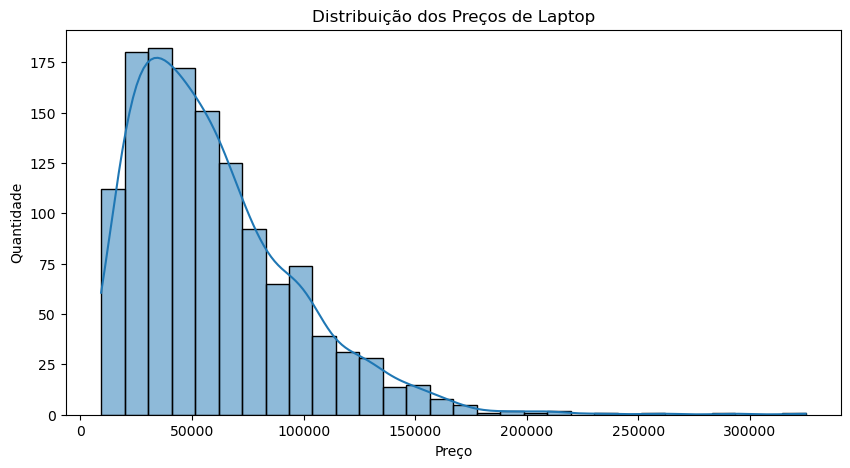

In [340]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribuição dos Preços de Laptop")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.show

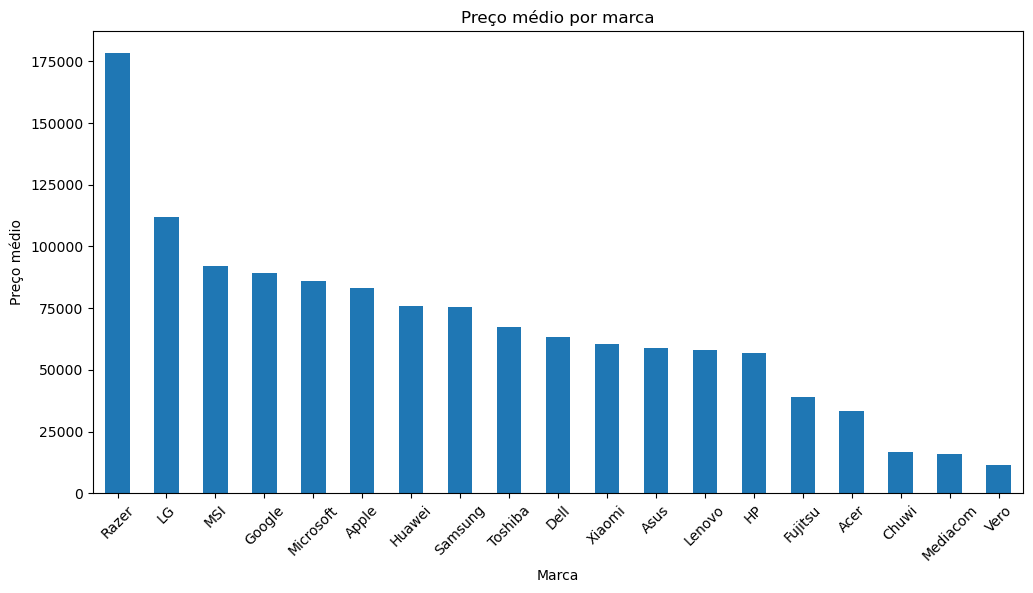

In [341]:
#Análise de Preço Médio por Marca

##tabular:
# df.groupby("Company")["Price"].mean().sort_values(ascending=False)

#distribuição visual:
plt.figure(figsize=(12, 6))
df.groupby("Company")["Price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Preço médio por marca")
plt.xlabel("Marca")
plt.ylabel("Preço médio")
plt.xticks(rotation=45)
plt.show()

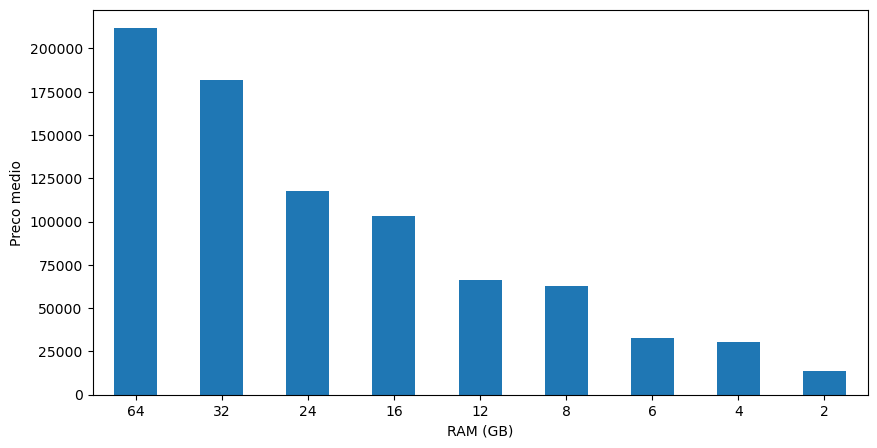

In [342]:
#Análise de Preço vs RAM

# df.groupby("Ram")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
df.groupby("Ram")["Price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.xlabel("RAM (GB)")
plt.ylabel("Preco medio")
plt.xticks(rotation=0)
plt.show()




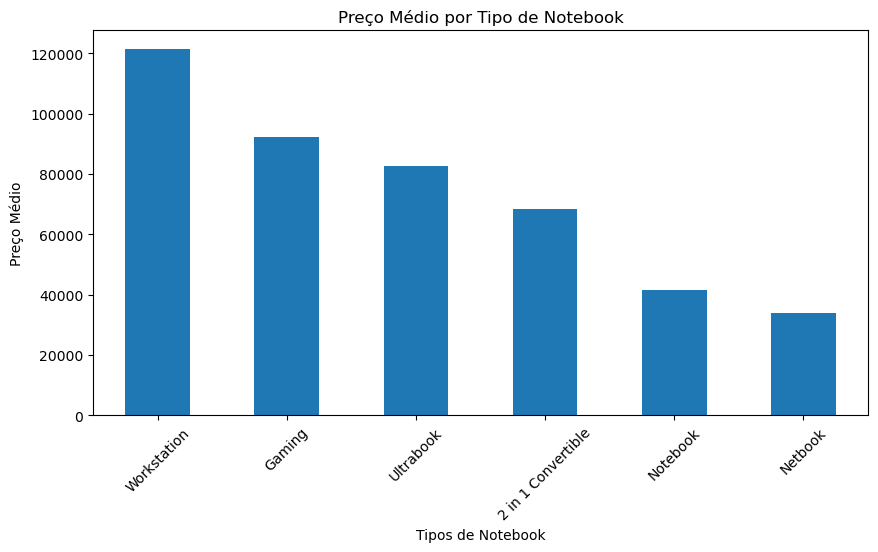

In [343]:
#Análise de Tipos de Notebook por Preço Médio

#Tabular:
# df.groupby("TypeName")["Price"].mean().sort_values(ascending=False)

#Gráfico:
plt.figure(figsize=(10,5))
df.groupby("TypeName")["Price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Preço Médio por Tipo de Notebook")
plt.xlabel("Tipos de Notebook")
plt.ylabel("Preço Médio")
plt.xticks(rotation=45)
plt.show()

In [344]:
# QUAIS NOTEBOOKS COMBINAM Menor Preço e Boa Quantidade de RAM?

df[["Company", "TypeName", "Ram", "Price"]].sort_values(by=["Ram", "Price"], ascending=[False, True]).head(10)

df["Custo_beneficio_ram"] = df["Ram"] / df["Price"]

df[["Company", "TypeName", "Ram", "Price", "Custo_beneficio_ram"]].sort_values(
    by="Custo_beneficio_ram",
    ascending=False
).head(10)

,Company,TypeName,Ram,Price,Custo_beneficio_ram
901,Asus,Gaming,32,68145.120,0.000470
783,Lenovo,Notebook,8,17529.120,0.000456
571,HP,Notebook,8,20725.920,0.000386
365,HP,Notebook,8,20725.920,0.000386
74,Acer,Notebook,8,20725.920,0.000386
1120,Vero,Notebook,4,10442.880,0.000383
634,Asus,Notebook,8,21258.720,0.000376
791,Vero,Notebook,4,10810.512,0.000370
588,Lenovo,Notebook,12,32447.520,0.000370
1102,Acer,Notebook,4,11135.520,0.000359


## Principais insights iniciais

A analise exploratoria mostrou que categorias como Workstations e Gaming apresentam os maiores precos medios, enquanto Netbooks ocupam a faixa mais acessivel do mercado.

Ao observar a relacao entre memoria RAM e preco, foi identificado que notebooks das marcas HP, Vero e Asus apresentam bom custo-beneficio relativo. Alem disso, a categoria Notebook se destacou como a mais equilibrada entre preco e usabilidade cotidiana.

Esses resultados sugerem que, para perfis de uso mais comuns no dia a dia, notebooks tradicionais podem oferecer melhor relacao entre configuracao e investimento.
